# 01. From Data to Inference

Statistical inference begins when a decision depends on an unknown population quantity and all we have is a finite sample. A sample can describe what happened in the observed data. Inference asks the harder question: **what does that sample imply about the larger system we care about?**

We use a synthetic support-operations audit. A marketplace team is considering whether to expand a premium enterprise support promise next quarter. Leadership wants to know whether current service performance is truly good enough in the target population across plausible audits.

That distinction is the heart of statistical inference. We do not act on raw sample summaries alone. We act on what the sample lets us credibly say about unknown population performance, sampling uncertainty, and the cost of being wrong.


## Learning Objectives

After working through this lecture, you should be able to:

1. Explain the difference between a descriptive summary and an inferential claim.
2. Distinguish a population parameter from a sample statistic.
3. Map an operational decision into explicit inferential targets.
4. Use repeated sampling to see why sample estimates vary from one audit to another.
5. Show how sample size changes inferential precision.
6. Explain why nonrepresentative sampling can create bias that larger samples do not fix.
7. Translate inferential evidence into a professional recommendation with explicit uncertainty.


### Dataset and Experiment Design

The dataset is a synthetic support-operations audit for a marketplace that is considering a premium enterprise support promise. Each row represents one support ticket. The variables include seller tier, ticket severity, region, channel, queue pressure, analyst tenure, automation assistance, resolution time, SLA breach status, and ticket cost.

The experiment has two views of the same operating system. First, we create a hidden population of tickets that represents the target process leadership actually cares about next quarter. Second, we draw audit samples from that population, including a random audit and a deliberately biased audit. This lets us compare population parameters with sample statistics and show why inferential claims need uncertainty, not just descriptive summaries.

The simulation is not meant to be a perfect support-business twin. It is a controlled teaching environment where the truth is visible, so we can see exactly how sampling variation and sampling bias affect a recommendation.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 120)
np.random.seed(2026)


def make_support_population(n=60_000, seed=310, sla_minutes=60):
    """
    Construct the support population object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
        sla_minutes: Decision or statistical threshold used to define the target, interval, or rule.
    
    Returns:
        A pandas DataFrame representing the simulated support population, including covariates, operational outcomes, and ground-truth targets used later for inference checks.
    
    Idea:
        Create a known synthetic population so sample estimates, intervals, likelihoods, and inference procedures can be checked against ground truth.
    """
    rng = np.random.default_rng(seed)

    seller_tier = rng.choice(['growth', 'enterprise'], size=n, p=[0.72, 0.28])
    severity = rng.choice(['routine', 'complex', 'urgent'], size=n, p=[0.55, 0.32, 0.13])
    region = rng.choice(['North', 'South', 'West', 'Central'], size=n, p=[0.24, 0.22, 0.29, 0.25])
    channel = rng.choice(['chat', 'email', 'phone'], size=n, p=[0.44, 0.31, 0.25])

    queue_pressure = np.clip(
        rng.normal(0.0, 0.85, n)
        + np.where(region == 'West', 0.18, 0.0)
        + np.where(region == 'South', 0.08, 0.0),
        -1.5,
        2.8,
    )
    analyst_tenure_years = rng.gamma(shape=3.5, scale=1.3, size=n)
    automation_assist = rng.binomial(
        1,
        p=np.where(severity == 'routine', 0.72, np.where(severity == 'complex', 0.48, 0.22)),
        size=n,
    )

    severity_base = {'routine': 30, 'complex': 48, 'urgent': 70}
    tier_effect = {'growth': -2, 'enterprise': 4}
    channel_effect = {'chat': -5, 'email': 2, 'phone': 7}
    region_effect = {'North': -2, 'South': 2, 'West': 4, 'Central': 0}

    service_noise = rng.normal(0, 7, n) + rng.gamma(2.3, 2.6, n)

    resolution_minutes = (
        np.vectorize(severity_base.get)(severity)
        + np.vectorize(tier_effect.get)(seller_tier)
        + np.vectorize(channel_effect.get)(channel)
        + np.vectorize(region_effect.get)(region)
        + 5.8 * queue_pressure
        - 1.8 * analyst_tenure_years
        - 6.0 * automation_assist
        + service_noise
    )
    resolution_minutes = np.clip(resolution_minutes, 5, None)

    sla_breach = (resolution_minutes > sla_minutes).astype(int)
    customer_credit = 18 * sla_breach + 0.12 * np.maximum(resolution_minutes - sla_minutes, 0) ** 1.1
    cost_per_ticket = 14 + 0.72 * resolution_minutes + customer_credit

    return pd.DataFrame(
        {
            'seller_tier': seller_tier,
            'severity': severity,
            'region': region,
            'channel': channel,
            'queue_pressure': queue_pressure,
            'analyst_tenure_years': analyst_tenure_years,
            'automation_assist': automation_assist,
            'resolution_minutes': resolution_minutes,
            'sla_breach': sla_breach,
            'cost_per_ticket': cost_per_ticket,
        }
    )


def summarize_targets(df):
    """
    Summarize targets into a compact table or record.
    
    Parameters:
        df: Input DataFrame used by the summary, model, or display helper.
    
    Returns:
        A dictionary of population target quantities, including mean resolution time, SLA breach rates, subgroup contrasts, and cost summaries.
    
    Idea:
        Connect sample estimates to target quantities so inference is framed as learning about a population decision parameter.
    """
    enterprise_mask = df['seller_tier'].eq('enterprise')
    growth_mask = df['seller_tier'].eq('growth')

    return {
        'mean_resolution_minutes': df['resolution_minutes'].mean(),
        'sla_breach_rate': df['sla_breach'].mean(),
        'enterprise_breach_rate': df.loc[enterprise_mask, 'sla_breach'].mean(),
        'enterprise_minus_growth_mean_gap': (
            df.loc[enterprise_mask, 'resolution_minutes'].mean()
            - df.loc[growth_mask, 'resolution_minutes'].mean()
        ),
    }


def repeated_sample_estimates(population, n, reps=1000, seed=0, weights=None):
    """
    Compute the repeated sample estimates quantity used in the statistical or decision-science workflow.
    
    Parameters:
        population: Input used by `population` in this helper.
        n: Number of observations, rows, or simulated units to generate.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        seed: Random seed used to make the simulation or resampling reproducible.
        weights: Input used by `weights` in this helper.
    
    Returns:
        A pandas DataFrame of repeated-sampling estimates for the notebook targets across simulated audits.
    
    Idea:
        Draw many samples from the same population to make sampling error visible as a distribution of estimates.
    """
    rng = np.random.default_rng(seed)
    population_index = np.arange(len(population))
    y = population['resolution_minutes'].to_numpy()
    breach = population['sla_breach'].to_numpy()
    tier = population['seller_tier'].to_numpy()

    draws = []
    for _ in range(reps):
        chosen = rng.choice(population_index, size=n, replace=False, p=weights)
        y_s = y[chosen]
        b_s = breach[chosen]
        t_s = tier[chosen]

        enterprise_mask = t_s == 'enterprise'
        growth_mask = t_s == 'growth'

        draws.append(
            {
                'mean_resolution_minutes': y_s.mean(),
                'sla_breach_rate': b_s.mean(),
                'enterprise_breach_rate': b_s[enterprise_mask].mean() if enterprise_mask.any() else np.nan,
                'enterprise_minus_growth_mean_gap': (
                    y_s[enterprise_mask].mean() - y_s[growth_mask].mean()
                    if enterprise_mask.any() and growth_mask.any()
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(draws)


def bootstrap_estimates(sample_df, reps=3000, seed=42):
    """
    Generate bootstrap-based estimates results from resampled data.
    
    Parameters:
        sample_df: Input used by `sample_df` in this helper.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of bootstrap estimates for the notebook targets computed from the observed audit sample.
    
    Idea:
        Treat the observed sample as an empirical population to show how much a statistic may move under repeated sampling.
    """
    rng = np.random.default_rng(seed)
    n = len(sample_df)
    draws = []
    for _ in range(reps):
        chosen = rng.integers(0, n, n)
        resample = sample_df.iloc[chosen]
        draws.append(summarize_targets(resample))
    return pd.DataFrame(draws)

## 1. What Makes a Claim Inferential?

Suppose an analyst says, "In our audit sample, 13.5% of tickets breached the SLA." That is a **descriptive statement about the observed sample**.

Now suppose the analyst says, "The underlying system is likely breaching the SLA at roughly 11% to 15%, so a full enterprise support promise would still be risky." That is an **inferential statement about an unknown population quantity**.

Inference matters because operational decisions are rarely about the sample itself. They are about the larger process that produced the sample and is likely to produce future cases as well.

A useful way to organize the logic is:

- the **parameter** is the population quantity we wish we knew;
- the **statistic** is what we compute from the observed sample;
- the **inferential task** is reasoning from the statistic back to the parameter;
- the **decision task** is determining whether the remaining uncertainty is acceptable for action.

Modern statistical guidance repeatedly warns against reducing this process to binary labels such as "significant" versus "not significant." Better practice emphasizes estimates, uncertainty, design quality, and practical consequences (Greenland et al., 2016; Wasserstein et al., 2019; Amrhein et al., 2019).


| Element | Version Used Here |
|---|---|
| Decision question | Should the marketplace expand a premium enterprise support promise next quarter? |
| Unit of analysis | One support ticket |
| Target population | Tickets that would be covered by the enterprise support promise next quarter |
| Main inferential targets | Mean resolution time, overall SLA breach rate, enterprise-ticket breach rate, and the enterprise-versus-growth resolution gap |
| Observed data | A finite quality-audit sample of tickets from the current system |
| Main risk if wrong | Leadership may overpromise service quality and create avoidable operational failures |
| Important warning | A segment difference is potentially noncausal; it may reflect case mix, channel mix, queue pressure, or the tier label itself |


This table does a lot of conceptual work.

First, it separates the **population decision problem** from the **sample evidence**. Second, it forces the inferential target to be explicit. Third, it keeps us honest about what the data do and do not support. If enterprise tickets resolve more slowly than growth tickets, that fact can be inferentially real without being causally interpretable.

That distinction will matter throughout this course. Statistical inference is about disciplined uncertainty. It is not a license to overread a sample.

## 2. A Synthetic Population and an Observed Audit Sample

To make inferential ideas visible, we will simulate a full support-ticket population and then draw an audit sample from it. In real work, analysts do **not** get to see the full population truth. Here we reveal it only because it is pedagogically useful.

The synthetic environment includes seller tier, severity, channel, region, queue pressure, analyst tenure, automation assistance, resolution time, breach status, and ticket cost. The audit sample will be a simple random sample of tickets. We will also create a deliberately biased audit later to show why representativeness matters as much as sample size.


In [2]:
# Simulate data or resample observations to study variability and uncertainty.
sla_minutes = 60
population = make_support_population(n=60_000, seed=310, sla_minutes=sla_minutes)
audit_sample = population.sample(n=1_000, random_state=2026).reset_index(drop=True)

bias_weights = (
    1
    + 1.6 * population['severity'].eq('urgent').to_numpy()
    + 0.9 * population['severity'].eq('complex').to_numpy()
    + 0.8 * population['region'].eq('West').to_numpy()
    + 0.5 * population['seller_tier'].eq('enterprise').to_numpy()
)
bias_weights = bias_weights / bias_weights.sum()
biased_audit_sample = population.iloc[
    np.random.default_rng(2027).choice(np.arange(len(population)), size=1_000, replace=False, p=bias_weights)
].reset_index(drop=True)

sample_overview = pd.DataFrame(
    [
        {
            'dataset': 'Hidden population',
            'rows': len(population),
            'enterprise_share': population['seller_tier'].eq('enterprise').mean(),
            'sla_breach_rate': population['sla_breach'].mean(),
            'mean_resolution_minutes': population['resolution_minutes'].mean(),
        },
        {
            'dataset': 'Observed audit sample',
            'rows': len(audit_sample),
            'enterprise_share': audit_sample['seller_tier'].eq('enterprise').mean(),
            'sla_breach_rate': audit_sample['sla_breach'].mean(),
            'mean_resolution_minutes': audit_sample['resolution_minutes'].mean(),
        },
        {
            'dataset': 'Biased audit sample',
            'rows': len(biased_audit_sample),
            'enterprise_share': biased_audit_sample['seller_tier'].eq('enterprise').mean(),
            'sla_breach_rate': biased_audit_sample['sla_breach'].mean(),
            'mean_resolution_minutes': biased_audit_sample['resolution_minutes'].mean(),
        },
    ]
)

sample_overview_display = sample_overview.copy()
for col in ['enterprise_share', 'sla_breach_rate']:
    sample_overview_display[col] = (100 * sample_overview_display[col]).map(lambda x: f"{x:0.1f}%")
sample_overview_display['mean_resolution_minutes'] = sample_overview_display['mean_resolution_minutes'].map(lambda x: f"{x:0.1f}")
smart_display(sample_overview_display)

smart_display(audit_sample.head(8))


,dataset,rows,enterprise_share,sla_breach_rate,mean_resolution_minutes
0,Hidden population,60000,27.9%,13.2%,36.8
1,Observed audit sample,1000,29.4%,13.5%,37.3
2,Biased audit sample,1000,34.7%,18.9%,41.3


,seller_tier,severity,region,channel,queue_pressure,analyst_tenure_years,automation_assist,resolution_minutes,sla_breach,cost_per_ticket
0,growth,complex,Central,phone,-0.024,8.494,1,42.403,0,44.530
1,growth,routine,West,phone,1.654,3.823,1,29.338,0,35.123
2,enterprise,routine,Central,phone,0.270,3.401,0,37.081,0,40.698
3,growth,complex,Central,chat,-1.059,2.233,1,23.972,0,31.259
4,growth,complex,North,chat,-0.546,8.059,1,20.242,0,28.574
5,growth,complex,Central,chat,-0.179,4.020,0,38.322,0,41.592
6,enterprise,routine,North,phone,0.950,3.308,0,39.485,0,42.429
7,growth,routine,South,email,-0.278,2.583,0,22.933,0,30.512


The synthetic audit now has a concrete service target: response time relative to an SLA. That matters because inference is never only about a table of numbers. The estimate needs to be interpreted against the business object it represents, the population it was sampled from, and the decision that will use it.

## Variable Guide

| Variable | Role | Why It Matters |
|---|---|---|
| `seller_tier` | Segment label | Enterprise tickets are the group leadership wants to serve more aggressively |
| `severity` | Case-mix driver | More severe tickets naturally take longer to resolve |
| `region` | Operational context | Workload and staffing conditions differ across regions |
| `channel` | Intake pathway | Chat, email, and phone create different service patterns |
| `queue_pressure` | System congestion | Higher pressure raises both average time and tail risk |
| `analyst_tenure_years` | Workforce capability | More experienced analysts tend to resolve tickets more efficiently |
| `automation_assist` | Workflow support | Automation can reduce time on routine work |
| `resolution_minutes` | Primary continuous outcome | Central inferential target for service reliability |
| `sla_breach` | Binary service failure | Operationally salient indicator of whether the support promise was missed |
| `cost_per_ticket` | Economic guardrail | Fast service that is too expensive may still be a poor decision |


The hidden population gives us an instructor's view of the truth. The audit sample gives us the analyst's view of the world. In practice, only the second is available.

Notice also that the biased sample already looks different from the random audit. It contains more urgent, enterprise, and West-region tickets because those were made more likely to appear in the review process. Later we will show that this changes the inferential conclusion in a systematic way.

## 3. Parameters, Estimands, and Sample Statistics

For the rest of the notebook, let `Y` denote ticket resolution time and let `B = I(Y > 60)` indicate whether the 60-minute SLA was breached.

The main population quantities are:

$$
\theta_{\text{mean}} = E[Y]
$$

$$
\theta_{\text{breach}} = P(B = 1)
$$

$$
\theta_{\text{enterprise breach}} = P(B = 1 \mid G = \text{enterprise})
$$

$$
\Delta_{E-G} = E[Y \mid G = \text{enterprise}] - E[Y \mid G = \text{growth}]
$$

Their sample analogues are computed from the observed audit:

$$
\hat{\theta}_{\text{mean}} = \frac{1}{n}\sum_{i=1}^{n} Y_i,
\qquad
\hat{\theta}_{\text{breach}} = \frac{1}{n}\sum_{i=1}^{n} B_i
$$

and similarly for subgroup rates and subgroup mean gaps.

The key inferential idea is simple but profound: **the parameter is fixed but unknown; the statistic is known after sampling but would have changed had we drawn a different sample.**


In [3]:
# Build a summary table that supports the interpretation in the surrounding notes.
population_targets = summarize_targets(population)
audit_targets = summarize_targets(audit_sample)

comparison_table = pd.DataFrame(
    [
        {
            'quantity': 'Mean resolution time',
            'population_truth': population_targets['mean_resolution_minutes'],
            'audit_estimate': audit_targets['mean_resolution_minutes'],
            'estimation_error': audit_targets['mean_resolution_minutes'] - population_targets['mean_resolution_minutes'],
            'practical_read': 'Average speed of the current support system',
        },
        {
            'quantity': 'Overall SLA breach rate',
            'population_truth': population_targets['sla_breach_rate'],
            'audit_estimate': audit_targets['sla_breach_rate'],
            'estimation_error': audit_targets['sla_breach_rate'] - population_targets['sla_breach_rate'],
            'practical_read': 'Chance that a ticket misses the 60-minute promise',
        },
        {
            'quantity': 'Enterprise-ticket breach rate',
            'population_truth': population_targets['enterprise_breach_rate'],
            'audit_estimate': audit_targets['enterprise_breach_rate'],
            'estimation_error': audit_targets['enterprise_breach_rate'] - population_targets['enterprise_breach_rate'],
            'practical_read': 'Risk carried by the premium segment specifically',
        },
        {
            'quantity': 'Enterprise minus growth mean gap',
            'population_truth': population_targets['enterprise_minus_growth_mean_gap'],
            'audit_estimate': audit_targets['enterprise_minus_growth_mean_gap'],
            'estimation_error': audit_targets['enterprise_minus_growth_mean_gap'] - population_targets['enterprise_minus_growth_mean_gap'],
            'practical_read': 'How much slower enterprise tickets look on average',
        },
    ]
)

comparison_display = comparison_table.copy()
for column in ['population_truth', 'audit_estimate', 'estimation_error']:
    comparison_display[column] = comparison_display.apply(
        lambda row: f"{100 * row[column]:0.2f}%" if 'rate' in row['quantity'].lower() else f"{row[column]:0.2f}",
        axis=1,
    )
smart_display(comparison_display)


,quantity,population_truth,audit_estimate,estimation_error,practical_read
0,Mean resolution time,36.79,37.33,0.54,Average speed of the current support system
1,Overall SLA breach rate,13.21%,13.50%,0.30%,Chance that a ticket misses the 60-minute promise
2,Enterprise-ticket breach rate,17.21%,18.37%,1.16%,Risk carried by the premium segment specifically
3,Enterprise minus growth mean gap,5.96,5.96,0.01,How much slower enterprise tickets look on average


The audit estimates are close to the hidden truth, but they are not exact. That gap is the most basic face of inferential uncertainty.

Two cautions are worth making explicit.

First, even a good random sample will not match the population perfectly. That is not a mistake; it is the normal behavior of sampling.

Second, the enterprise-versus-growth gap is a subgroup comparison, not a causal effect. Enterprise tickets may be slower because they are harder, because they route differently, or because they arrive under different operating conditions. Inference tells us whether the gap likely exists in the population. Causal analysis would ask why.

## 4. Repeated Sampling Makes Uncertainty Visible

One sample is what an analyst actually gets. But statistical theory often imagines the sampling process repeated over and over. That thought experiment is powerful because it reveals how much an estimate would move across equally valid audits.

We will repeatedly draw random audit samples of the same size as the observed audit and track the resulting sample mean and sample breach rate. This is not yet formal interval estimation; it is an inferential visualization of sampling variability.


,target,true_value,average_across_audits,sampling_sd,middle_95_percent_of_audits
0,Mean resolution time,36.79,36.78,0.60,"[35.63, 37.98]"
1,Overall SLA breach rate,13.21%,13.21%,1.06%,"[11.20%, 15.30%]"


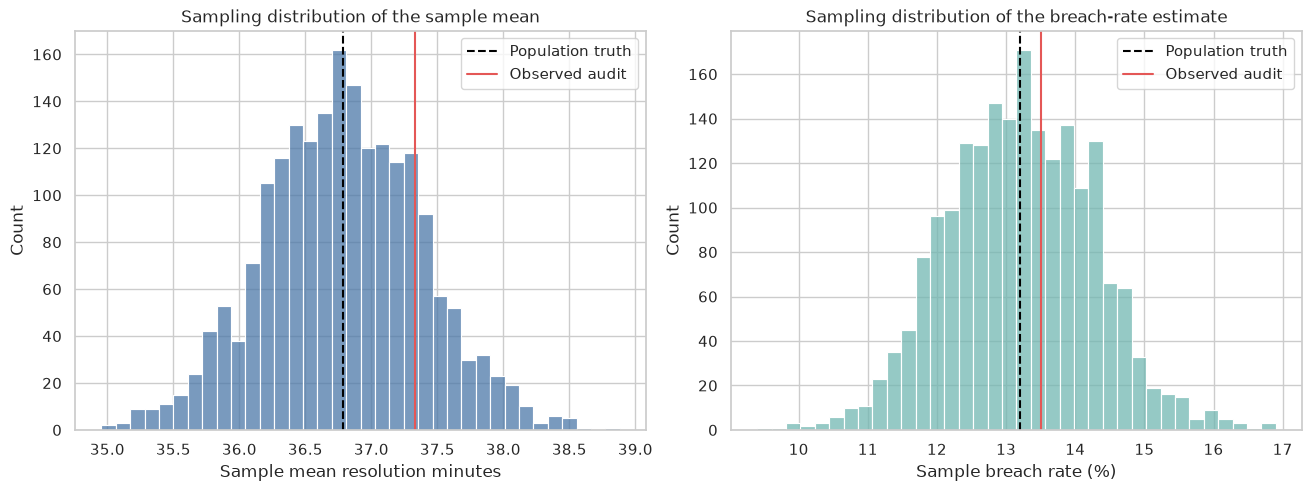

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
sampling_draws = repeated_sample_estimates(population, n=len(audit_sample), reps=2_000, seed=44)

sampling_summary = pd.DataFrame(
    [
        {
            'target': 'Mean resolution time',
            'true_value': population_targets['mean_resolution_minutes'],
            'average_across_audits': sampling_draws['mean_resolution_minutes'].mean(),
            'sampling_sd': sampling_draws['mean_resolution_minutes'].std(ddof=1),
            'middle_95_percent_of_audits': f"[{sampling_draws['mean_resolution_minutes'].quantile(0.025):0.2f}, {sampling_draws['mean_resolution_minutes'].quantile(0.975):0.2f}]",
        },
        {
            'target': 'Overall SLA breach rate',
            'true_value': population_targets['sla_breach_rate'],
            'average_across_audits': sampling_draws['sla_breach_rate'].mean(),
            'sampling_sd': sampling_draws['sla_breach_rate'].std(ddof=1),
            'middle_95_percent_of_audits': f"[{100 * sampling_draws['sla_breach_rate'].quantile(0.025):0.2f}%, {100 * sampling_draws['sla_breach_rate'].quantile(0.975):0.2f}%]",
        },
    ]
)

sampling_summary_display = sampling_summary.copy()
for column in ['true_value', 'average_across_audits', 'sampling_sd']:
    sampling_summary_display[column] = sampling_summary_display.apply(
        lambda row: f"{100 * row[column]:0.2f}%" if 'breach rate' in row['target'].lower() else f"{row[column]:0.2f}",
        axis=1,
    )
smart_display(sampling_summary_display)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

sns.histplot(sampling_draws['mean_resolution_minutes'], bins=36, color='#4C78A8', ax=axes[0])
axes[0].axvline(population_targets['mean_resolution_minutes'], color='black', linestyle='--', linewidth=1.5, label='Population truth')
axes[0].axvline(audit_targets['mean_resolution_minutes'], color='#E45756', linestyle='-', linewidth=1.5, label='Observed audit')
axes[0].set_title('Sampling distribution of the sample mean')
axes[0].set_xlabel('Sample mean resolution minutes')
axes[0].legend()

sns.histplot(100 * sampling_draws['sla_breach_rate'], bins=36, color='#72B7B2', ax=axes[1])
axes[1].axvline(100 * population_targets['sla_breach_rate'], color='black', linestyle='--', linewidth=1.5, label='Population truth')
axes[1].axvline(100 * audit_targets['sla_breach_rate'], color='#E45756', linestyle='-', linewidth=1.5, label='Observed audit')
axes[1].set_title('Sampling distribution of the breach-rate estimate')
axes[1].set_xlabel('Sample breach rate (%)')
axes[1].legend()

plt.show()


Several important ideas show up in these plots.

- The sampling distributions are centered near the population truth, which is what we want from an unbiased estimator under random sampling.
- The observed audit is only **one draw** from these distributions. Another equally valid audit would have produced slightly different numbers.
- The breach-rate estimate is noisier than it may first appear. A single audit reading of 13% is an estimate with sampling error. The data are compatible with a range of nearby values.

This is why inferential language matters. The right question is not, "What number did the audit produce?" It is, "What range of population performance is still plausible after seeing that audit?"

## 5. Sample Size Changes Precision, Not the Meaning of the Target

Larger samples usually produce more stable estimates, but they do not change the inferential target itself. We are still estimating the same population quantities. What changes is the width of the sampling distribution.

We will compare several audit sizes and measure how much the sample mean and sample breach-rate estimate fluctuate across repeated random samples.


,sample_size,sd_of_mean_estimate,middle_95_width_mean,sd_of_breach_estimate,middle_95_width_breach
0,150,1.471,5.725,2.59%,10.00%
1,400,0.920,3.616,1.69%,6.75%
2,1000,0.622,2.360,1.08%,4.10%
3,2500,0.376,1.424,0.67%,2.52%


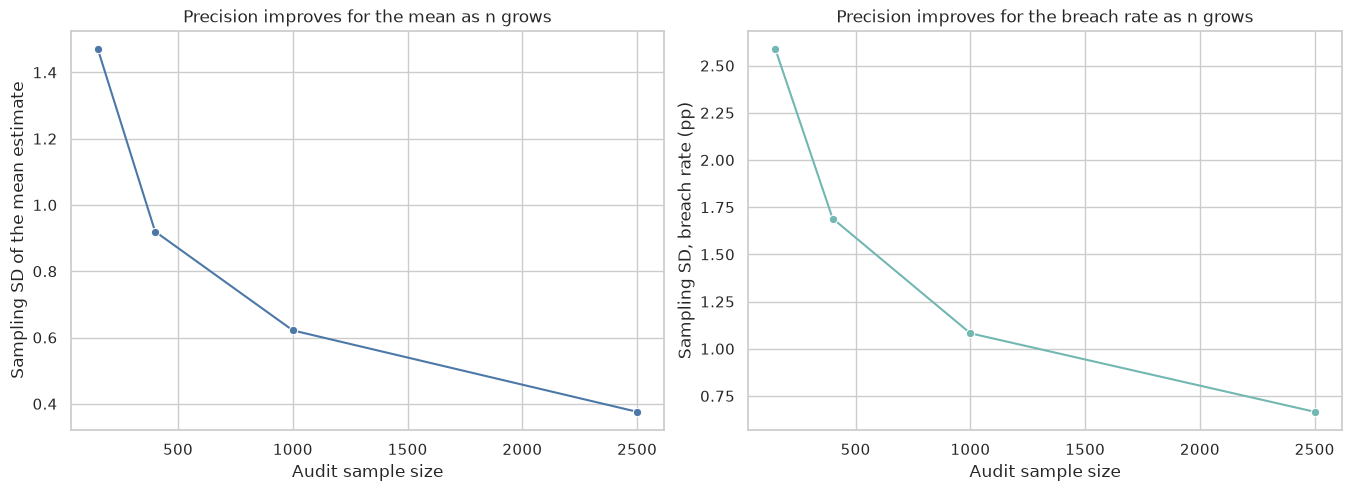

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
sample_sizes = [150, 400, 1_000, 2_500]
precision_rows = []
mean_sd_by_n = []
breach_sd_by_n = []

for n in sample_sizes:
    draws_n = repeated_sample_estimates(population, n=n, reps=800, seed=100 + n)
    precision_rows.append(
        {
            'sample_size': n,
            'sd_of_mean_estimate': draws_n['mean_resolution_minutes'].std(ddof=1),
            'middle_95_width_mean': draws_n['mean_resolution_minutes'].quantile(0.975) - draws_n['mean_resolution_minutes'].quantile(0.025),
            'sd_of_breach_estimate': draws_n['sla_breach_rate'].std(ddof=1),
            'middle_95_width_breach': draws_n['sla_breach_rate'].quantile(0.975) - draws_n['sla_breach_rate'].quantile(0.025),
        }
    )
    mean_sd_by_n.append({'sample_size': n, 'sampling_sd': draws_n['mean_resolution_minutes'].std(ddof=1)})
    breach_sd_by_n.append({'sample_size': n, 'sampling_sd': draws_n['sla_breach_rate'].std(ddof=1)})

precision_table = pd.DataFrame(precision_rows)
precision_display = precision_table.copy()
precision_display['sd_of_mean_estimate'] = precision_display['sd_of_mean_estimate'].map(lambda x: f"{x:0.3f}")
precision_display['middle_95_width_mean'] = precision_display['middle_95_width_mean'].map(lambda x: f"{x:0.3f}")
for col in ['sd_of_breach_estimate', 'middle_95_width_breach']:
    precision_display[col] = (100 * precision_display[col]).map(lambda x: f"{x:0.2f}%")
smart_display(precision_display)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8), constrained_layout=True)

sns.lineplot(data=pd.DataFrame(mean_sd_by_n), x='sample_size', y='sampling_sd', marker='o', ax=axes[0], color='#4C78A8')
axes[0].set_title('Precision improves for the mean as n grows')
axes[0].set_xlabel('Audit sample size')
axes[0].set_ylabel('Sampling SD of the mean estimate')

breach_sd_plot = pd.DataFrame(breach_sd_by_n).copy()
breach_sd_plot['sampling_sd_pct'] = 100 * breach_sd_plot['sampling_sd']
sns.lineplot(data=breach_sd_plot, x='sample_size', y='sampling_sd_pct', marker='o', ax=axes[1], color='#72B7B2')
axes[1].set_title('Precision improves for the breach rate as n grows')
axes[1].set_xlabel('Audit sample size')
axes[1].set_ylabel('Sampling SD, breach rate (pp)')

plt.show()


The pattern is exactly what statistical intuition predicts: bigger audits produce tighter inferential distributions.

That said, sample size is not a magic wand. A large sample can reduce random noise while still giving the wrong answer if the sampling design is systematically distorted. Precision and representativeness are not the same thing. The next section makes that difference concrete.

## 6. Why Design Quality Matters as Much as Sample Size

Suppose the audit process oversamples urgent tickets, enterprise tickets, and the West region because those are the cases most likely to attract managerial attention. That might sound reasonable operationally, but it changes the inferential object. The audit is no longer a random window into the target population.

We will compare repeated random audits with repeated biased audits of the same size.


,design,average_mean_resolution,bias_in_mean_minutes,average_breach_rate,bias_in_breach_rate
0,Random audit,36.76,-0.03,13.20%,-0.00%
1,Biased audit,42.14,+5.36,20.30%,+7.10%


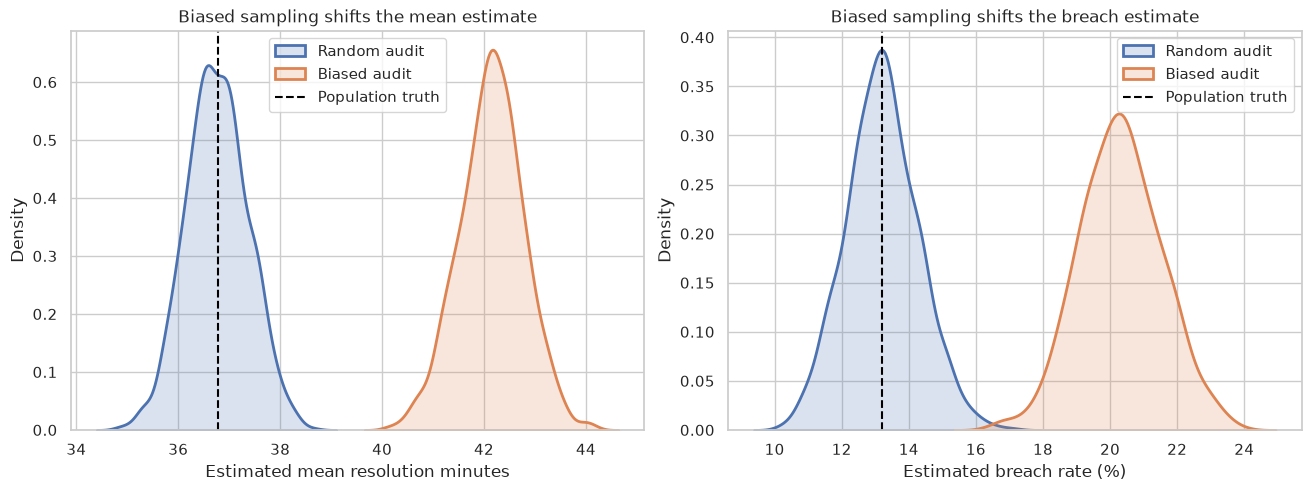

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
random_design_draws = repeated_sample_estimates(population, n=1_000, reps=1_000, seed=81)
biased_design_draws = repeated_sample_estimates(population, n=1_000, reps=1_000, seed=82, weights=bias_weights)

random_vs_biased = pd.DataFrame(
    [
        {
            'design': 'Random audit',
            'average_mean_resolution': random_design_draws['mean_resolution_minutes'].mean(),
            'bias_in_mean_minutes': random_design_draws['mean_resolution_minutes'].mean() - population_targets['mean_resolution_minutes'],
            'average_breach_rate': random_design_draws['sla_breach_rate'].mean(),
            'bias_in_breach_rate': random_design_draws['sla_breach_rate'].mean() - population_targets['sla_breach_rate'],
        },
        {
            'design': 'Biased audit',
            'average_mean_resolution': biased_design_draws['mean_resolution_minutes'].mean(),
            'bias_in_mean_minutes': biased_design_draws['mean_resolution_minutes'].mean() - population_targets['mean_resolution_minutes'],
            'average_breach_rate': biased_design_draws['sla_breach_rate'].mean(),
            'bias_in_breach_rate': biased_design_draws['sla_breach_rate'].mean() - population_targets['sla_breach_rate'],
        },
    ]
)

random_vs_biased_display = random_vs_biased.copy()
random_vs_biased_display['average_mean_resolution'] = random_vs_biased_display['average_mean_resolution'].map(lambda x: f"{x:0.2f}")
random_vs_biased_display['bias_in_mean_minutes'] = random_vs_biased_display['bias_in_mean_minutes'].map(lambda x: f"{x:+0.2f}")
random_vs_biased_display['average_breach_rate'] = (100 * random_vs_biased_display['average_breach_rate']).map(lambda x: f"{x:0.2f}%")
random_vs_biased_display['bias_in_breach_rate'] = (100 * random_vs_biased_display['bias_in_breach_rate']).map(lambda x: f"{x:+0.2f}%")
smart_display(random_vs_biased_display)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

sns.kdeplot(random_design_draws['mean_resolution_minutes'], fill=True, alpha=0.20, linewidth=2, label='Random audit', ax=axes[0])
sns.kdeplot(biased_design_draws['mean_resolution_minutes'], fill=True, alpha=0.20, linewidth=2, label='Biased audit', ax=axes[0])
axes[0].axvline(population_targets['mean_resolution_minutes'], color='black', linestyle='--', linewidth=1.5, label='Population truth')
axes[0].set_title('Biased sampling shifts the mean estimate')
axes[0].set_xlabel('Estimated mean resolution minutes')
axes[0].legend()

sns.kdeplot(100 * random_design_draws['sla_breach_rate'], fill=True, alpha=0.20, linewidth=2, label='Random audit', ax=axes[1])
sns.kdeplot(100 * biased_design_draws['sla_breach_rate'], fill=True, alpha=0.20, linewidth=2, label='Biased audit', ax=axes[1])
axes[1].axvline(100 * population_targets['sla_breach_rate'], color='black', linestyle='--', linewidth=1.5, label='Population truth')
axes[1].set_title('Biased sampling shifts the breach estimate')
axes[1].set_xlabel('Estimated breach rate (%)')
axes[1].legend()

plt.show()


This section is one of the most important in the notebook.

The biased audit changes the estimand being approximated. It is **systematically shifted** away from the population truth. That means larger biased samples would simply give us more confidence in the wrong inferential answer.

This is why design comes first. Statistical inference connects mathematics, data, and the target decision. It is mathematics layered on top of a sampling process. If that process does not align with the target population, the inferential story can break before any model is fit.

## 7. Turning Inferential Evidence Into a Recommendation

A stakeholder rarely wants a lecture about sampling distributions. They want a recommendation that reflects what the sample says, how uncertain that statement remains, and what action is justified right now.

We will use the observed audit sample and a simple bootstrap uncertainty sketch to summarize three quantities leadership would care about:

- overall mean resolution time,
- overall breach rate,
- enterprise-ticket breach rate.

Interval construction gets more careful later in the course. Here, the goal is to show how inferential reasoning feeds a professional decision memo.


In [7]:
# Simulate data or resample observations to study variability and uncertainty.
bootstrap_draws = bootstrap_estimates(audit_sample, reps=3_000, seed=91)

uncertainty_summary = pd.DataFrame(
    [
        {
            'quantity': 'Mean resolution time',
            'estimate': audit_targets['mean_resolution_minutes'],
            'bootstrap_middle_95': f"[{bootstrap_draws['mean_resolution_minutes'].quantile(0.025):0.2f}, {bootstrap_draws['mean_resolution_minutes'].quantile(0.975):0.2f}] minutes",
        },
        {
            'quantity': 'Overall SLA breach rate',
            'estimate': audit_targets['sla_breach_rate'],
            'bootstrap_middle_95': f"[{100 * bootstrap_draws['sla_breach_rate'].quantile(0.025):0.2f}%, {100 * bootstrap_draws['sla_breach_rate'].quantile(0.975):0.2f}%]",
        },
        {
            'quantity': 'Enterprise-ticket breach rate',
            'estimate': audit_targets['enterprise_breach_rate'],
            'bootstrap_middle_95': f"[{100 * bootstrap_draws['enterprise_breach_rate'].quantile(0.025):0.2f}%, {100 * bootstrap_draws['enterprise_breach_rate'].quantile(0.975):0.2f}%]",
        },
    ]
)

uncertainty_display = uncertainty_summary.copy()
uncertainty_display['estimate'] = uncertainty_display.apply(
    lambda row: f"{100 * row['estimate']:0.2f}%" if 'rate' in row['quantity'].lower() else f"{row['estimate']:0.2f} minutes",
    axis=1,
)
smart_display(uncertainty_display)

overall_breach_high = bootstrap_draws['sla_breach_rate'].quantile(0.975)
enterprise_breach_high = bootstrap_draws['enterprise_breach_rate'].quantile(0.975)

if overall_breach_high <= 0.12 and enterprise_breach_high <= 0.16:
    recommendation = 'Proceed with the full enterprise support promise.'
    rationale = 'Both overall and enterprise-specific breach uncertainty remain below the launch thresholds.'
elif overall_breach_high <= 0.15 and enterprise_breach_high <= 0.22:
    recommendation = 'Continue a limited pilot, but do not make a broad external promise yet.'
    rationale = 'Average performance looks workable, but enterprise-segment tail risk is still high enough that a universal promise would be premature.'
else:
    recommendation = 'Delay expansion and address service risk before expanding the promise.'
    rationale = 'The sample remains compatible with too much operational failure in the target segment.'

memo = (
    f"### Decision Memo\n\n"
    f"**Recommendation:** {recommendation}\n\n"
    f"**Why:**\n\n"
    f"- The audit estimates mean resolution time at **{audit_targets['mean_resolution_minutes']:.1f} minutes**.\n"
    f"- The estimated overall SLA breach rate is **{100 * audit_targets['sla_breach_rate']:.1f}%**, with a bootstrap middle-95% range of **[{100 * bootstrap_draws['sla_breach_rate'].quantile(0.025):.1f}%, {100 * bootstrap_draws['sla_breach_rate'].quantile(0.975):.1f}%]**.\n"
    f"- The estimated enterprise-ticket breach rate is **{100 * audit_targets['enterprise_breach_rate']:.1f}%**, with a bootstrap middle-95% range of **[{100 * bootstrap_draws['enterprise_breach_rate'].quantile(0.025):.1f}%, {100 * bootstrap_draws['enterprise_breach_rate'].quantile(0.975):.1f}%]**.\n\n"
    f"**Interpretation:** {rationale}\n\n"
    f"This is an inferential recommendation, not a claim of certainty. It summarizes what the current audit implies about the broader support system. Decision-oriented statistical work benefits from communicating uncertainty directly and, when useful, from asking what better information would be worth before acting (Raftery, 2016; Sadatsafavi et al., 2022)."
)

display(Markdown(memo))


,quantity,estimate,bootstrap_middle_95
0,Mean resolution time,37.33 minutes,"[36.18, 38.50] minutes"
1,Overall SLA breach rate,13.50%,"[11.50%, 15.70%]"
2,Enterprise-ticket breach rate,18.37%,"[14.09%, 22.88%]"


### Decision Memo

**Recommendation:** Delay expansion and address service risk before expanding the promise.

**Why:**

- The audit estimates mean resolution time at **37.3 minutes**.
- The estimated overall SLA breach rate is **13.5%**, with a bootstrap middle-95% range of **[11.5%, 15.7%]**.
- The estimated enterprise-ticket breach rate is **18.4%**, with a bootstrap middle-95% range of **[14.1%, 22.9%]**.

**Interpretation:** The sample remains compatible with too much operational failure in the target segment.

This is an inferential recommendation, not a claim of certainty. It summarizes what the current audit implies about the broader support system. Decision-oriented statistical work benefits from communicating uncertainty directly and, when useful, from asking what better information would be worth before acting (Raftery, 2016; Sadatsafavi et al., 2022).

<!-- real-data-companion-course01 -->
## Real-Data Companion: RAND HIE as an Inferential Dataset

The synthetic audit above lets us define the population, sample, estimand, and statistic with complete control. The RAND Health Insurance Experiment gives us a real policy dataset with the same inferential structure. The study randomized families into health-insurance plans with different cost-sharing levels, and the statsmodels version includes utilization and health-related variables derived from that experiment.

In this companion, the unit is an observed person-period record. The outcome `mdvis` is the number of outpatient physician visits, and `lncoins` encodes the assigned coinsurance level on a transformed scale. We use `lncoins == 0` as the free-care group and compare it with records under cost sharing.

The experiment in this lecture is deliberately narrow: define a target quantity, compute an observed statistic, and explain uncertainty in plain language. It is not a full health-economics evaluation. A full policy analysis would model plan details, costs, health outcomes, household structure, and external validity. Here the real data are used to practice the first inferential move from raw records to a defensible question.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

,plan_group,records,mean_visits,median_visits,any_visit_rate,p90_visits
0,Cost sharing,9193,2.546,1.000,0.648,6.000
1,Free care,10997,3.124,2.000,0.721,8.000


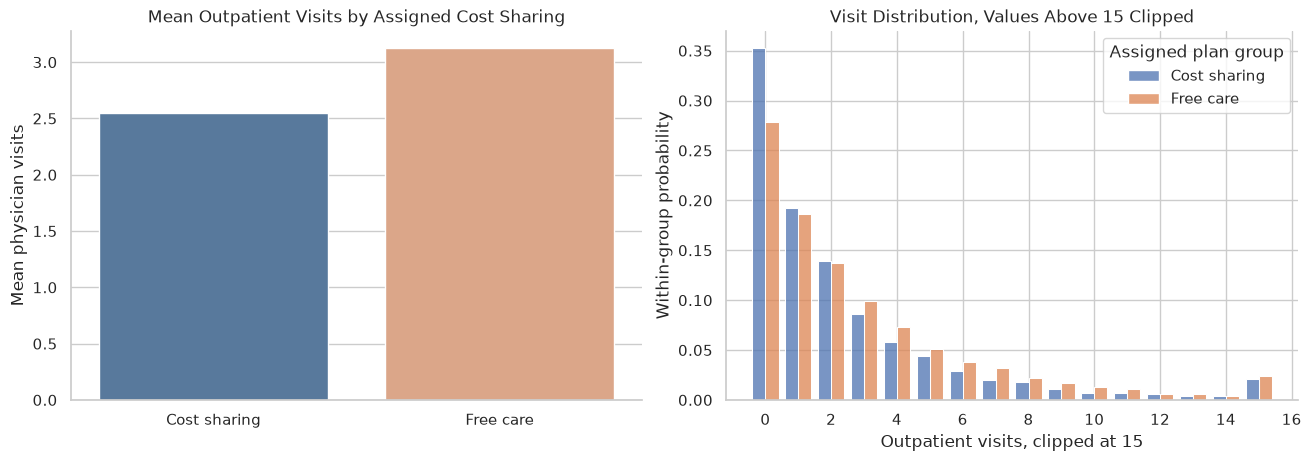

In [8]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rand_hie = load_statsmodels_randhie().copy()
    rand_hie["coinsurance"] = np.expm1(rand_hie["lncoins"]).round().clip(0, 100)
    rand_hie["plan_group"] = np.where(rand_hie["coinsurance"].eq(0), "Free care", "Cost sharing")
    rand_hie["any_visit"] = rand_hie["mdvis"].gt(0).astype(int)

    plan_summary = (
        rand_hie.groupby("plan_group")
        .agg(
            records=("mdvis", "size"),
            mean_visits=("mdvis", "mean"),
            median_visits=("mdvis", "median"),
            any_visit_rate=("any_visit", "mean"),
            p90_visits=("mdvis", lambda s: s.quantile(0.90)),
        )
        .reset_index()
    )
    smart_display(plan_summary.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    sns.barplot(data=plan_summary, x="plan_group", y="mean_visits", hue="plan_group", ax=axes[0], palette=["#4C78A8", "#E9A27B"], legend=False)
    axes[0].set_title("Mean Outpatient Visits by Assigned Cost Sharing")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Mean physician visits")

    plot_df = rand_hie.assign(mdvis_clipped=rand_hie["mdvis"].clip(upper=15))
    sns.histplot(
        data=plot_df,
        x="mdvis_clipped",
        hue="plan_group",
        stat="probability",
        common_norm=False,
        discrete=True,
        multiple="dodge",
        shrink=0.8,
        ax=axes[1],
    )
    axes[1].set_title("Visit Distribution, Values Above 15 Clipped")
    axes[1].set_xlabel("Outpatient visits, clipped at 15")
    axes[1].set_ylabel("Within-group probability")
    legend = axes[1].get_legend()
    if legend is not None:
        legend.set_title("Assigned plan group")
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )

<!-- real-data-companion-course01 -->
The real-data comparison is intentionally modest. The rows are actual observations from a major randomized policy experiment, but the table is still only the beginning of inference. It identifies the empirical contrast, checks the outcome scale, and reveals that utilization is a count outcome with a heavy right tail. Those facts should shape the estimand, the uncertainty method, and the language of any recommendation.

## 8. What to Remember

We established the basic workflow for the course.

1. Start with a real decision and define the population quantity that matters.
2. Separate the unknown parameter from the observed sample statistic.
3. Use repeated-sample thinking to understand variability across audits.
4. Remember that larger samples reduce random error but do not repair biased sampling.
5. Communicate inferential uncertainty in language a decision-maker can actually use.

The next notebook moves deeper into the machinery behind these ideas by studying sampling distributions and asymptotic approximations more formally.


## References

- Amrhein, V., Greenland, S., & McShane, B. (2019). *Scientists rise up against statistical significance*. *Nature, 567*(7748), 305-307. [https://doi.org/10.1038/d41586-019-00857-9](https://doi.org/10.1038/d41586-019-00857-9)
- Greenland, S., Senn, S. J., Rothman, K. J., Carlin, J. B., Poole, C., Goodman, S. N., & Altman, D. G. (2016). *Statistical tests, P values, confidence intervals, and power: a guide to misinterpretations*. *European Journal of Epidemiology, 31*(4), 337-350. [https://doi.org/10.1007/s10654-016-0149-3](https://doi.org/10.1007/s10654-016-0149-3)
- Raftery, A. E. (2016). *Use and communication of probabilistic forecasts*. *Statistical Analysis and Data Mining: The ASA Data Science Journal, 9*(6), 397-410. [https://doi.org/10.1002/sam.11302](https://doi.org/10.1002/sam.11302)
- Sadatsafavi, M., Lee, T. Y., & Gustafson, P. (2022). *Uncertainty and the value of information in risk prediction modeling*. *Medical Decision Making, 42*(5), 661-671. [https://doi.org/10.1177/0272989X221078789](https://doi.org/10.1177/0272989X221078789)
- Wasserstein, R. L., Schirm, A. L., & Lazar, N. A. (2019). *Moving to a World Beyond "p < 0.05"*. *The American Statistician, 73*(sup1), 1-19. [https://doi.org/10.1080/00031305.2019.1583913](https://doi.org/10.1080/00031305.2019.1583913)
